Explanatory Data Analysis on IMDB Movie Dataset
Loading the data set

Objective 1: Getting to Know Our Movies
First few movies:
   Rank                    Title                     Genre  \
0     1  Guardians of the Galaxy   Action,Adventure,Sci-Fi   
1     2               Prometheus  Adventure,Mystery,Sci-Fi   
2     3                    Split           Horror,Thriller   
3     4                     Sing   Animation,Comedy,Family   
4     5            Suicide Squad  Action,Adventure,Fantasy   

                                         Description              Director  \
0  A group of intergalactic criminals are forced ...            James Gunn   
1  Following clues to the origin of mankind, a te...          Ridley Scott   
2  Three girls are kidnapped by a man with a diag...    M. Night Shyamalan   
3  In a city of humanoid animals, a hustling thea...  Christophe Lourdelet   
4  A secret government agency recruits some of th...            David Ayer   

                              

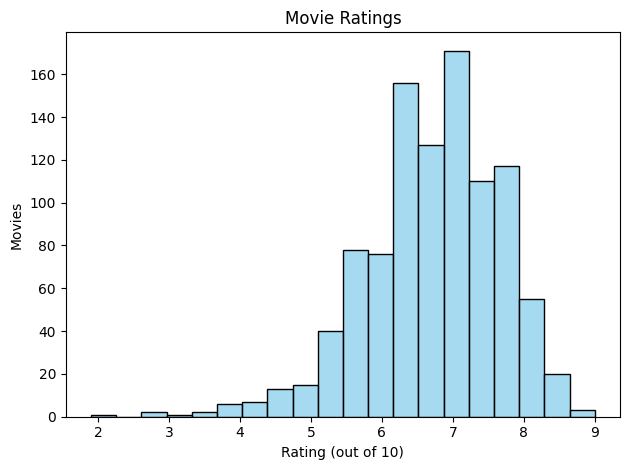


Objective 2: Do High Ratings Bring in the Cash?
Correlations:
                      Rating  Metascore  Revenue (Millions)
Rating              1.000000   0.604522            0.189527
Metascore           0.604522   1.000000            0.131868
Revenue (Millions)  0.189527   0.131868            1.000000

Graph 2: Rating and Metascore vs. Revenue


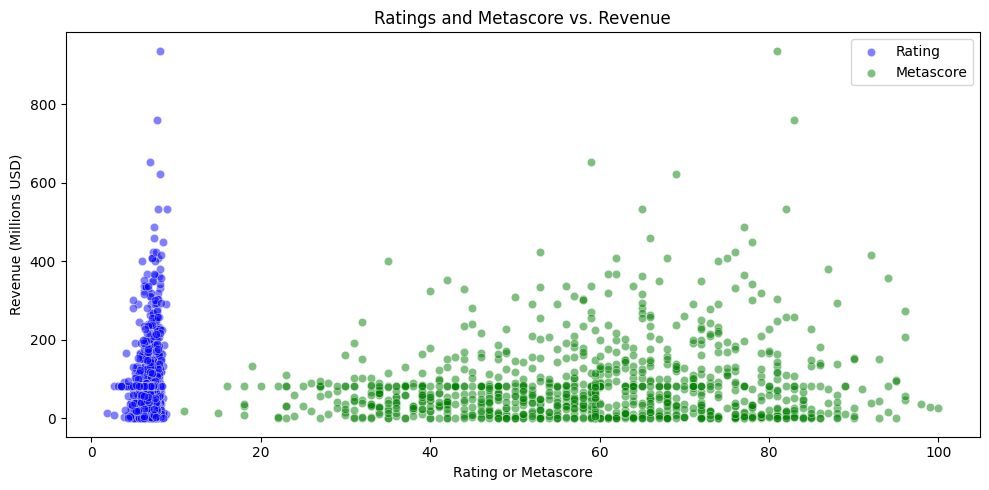


Average revenue by rating levels:
Rating
Low (0-5)        70.301921
Okay (5-6.5)     64.938142
Good (6.5-8)     89.166269
Great (8-10)    142.667551
Name: Revenue (Millions), dtype: float64

Graph 3: Revenue by rating groups


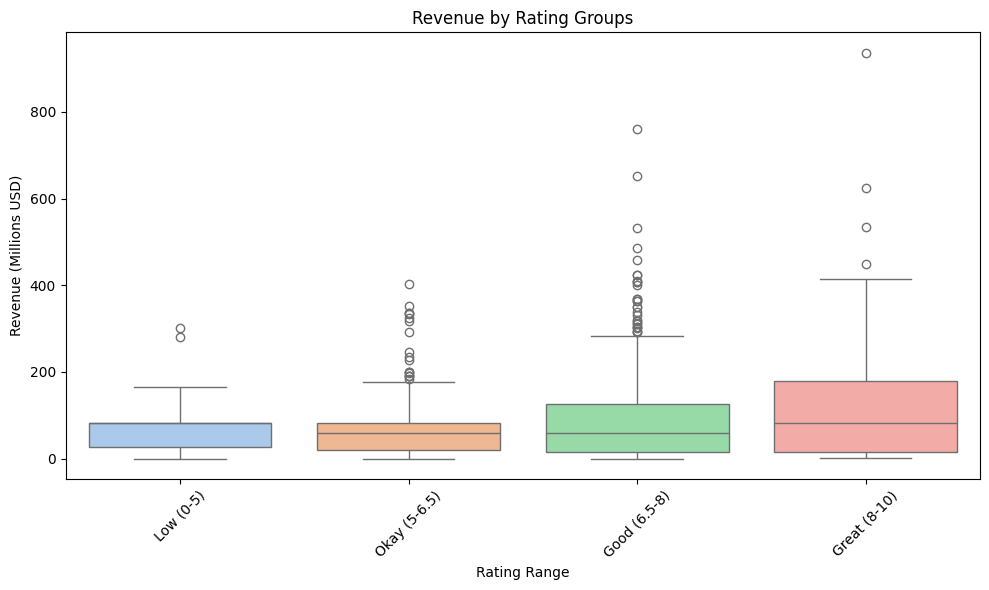


Objective 3: Movies Over the Years
Movies per year:
 Year
2006     44
2007     53
2008     52
2009     51
2010     60
2011     63
2012     64
2013     91
2014     98
2015    127
2016    297
Name: count, dtype: int64

Graph 4: Movies per year (line)


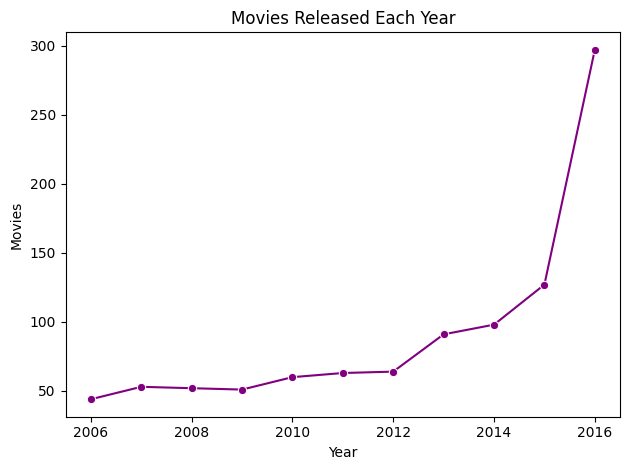


Graph 5: Movies per year (bar)


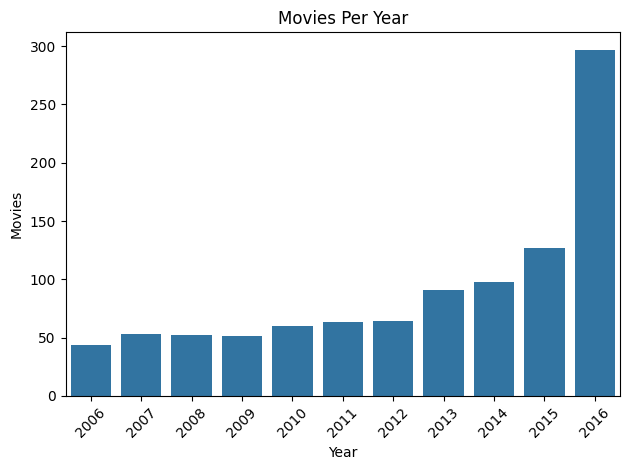


Busiest year: 2016 with 297 movies
Quietest year: 2006 with 44 movies

Objective 4: Exploring Genres

Most common genres:

Graph 6: Popular genres


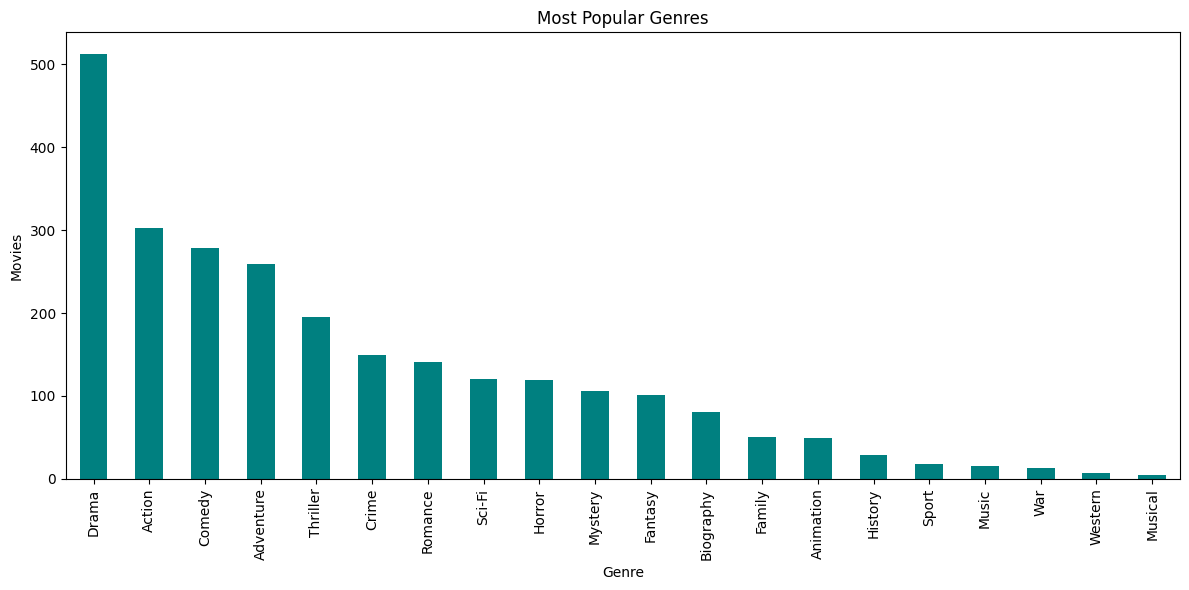


Graph 7: Average rating by genre


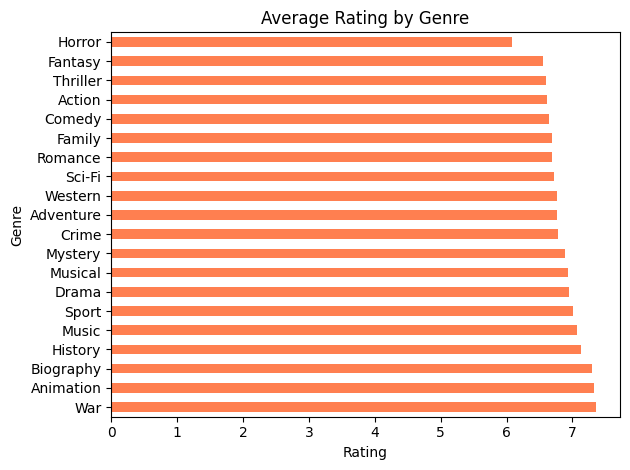


Graph 8: Average revenue by genre


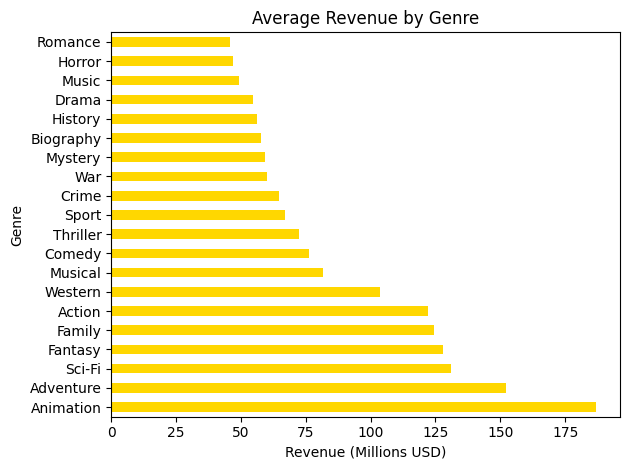


Objective 5: Spotlight on Directors
Missing directors: 0

Top 10 directors by movie count:

Graph 9: Directors with most movies


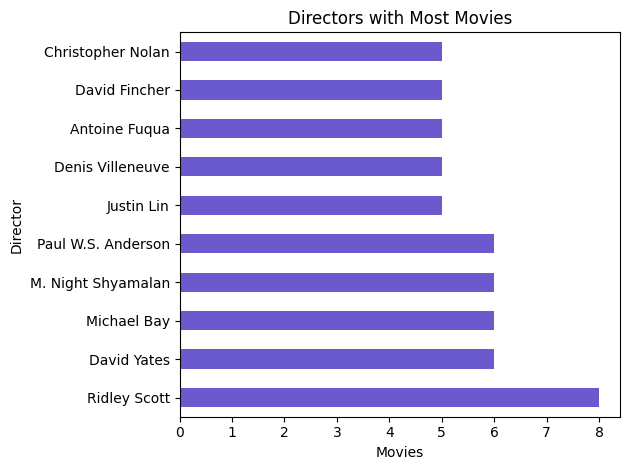


Graph 10: Top directors by average rating


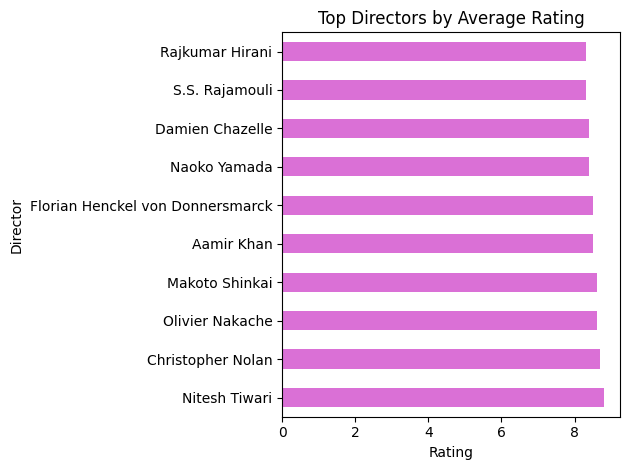


Graph 11: Directors with most high-rated movies (8+)


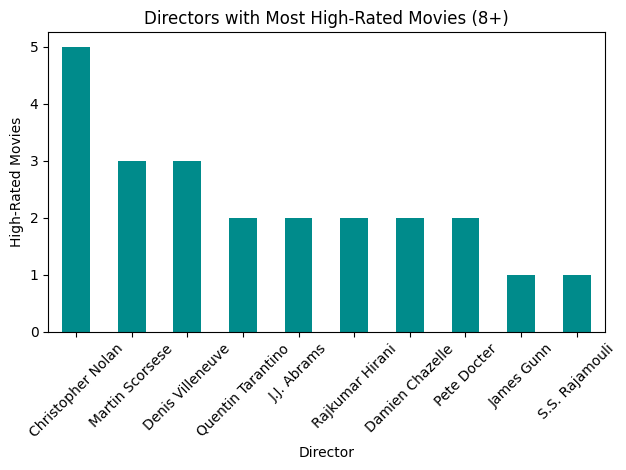


Objective 6: Movie Trends Over Time

Graph 12: Movies per year


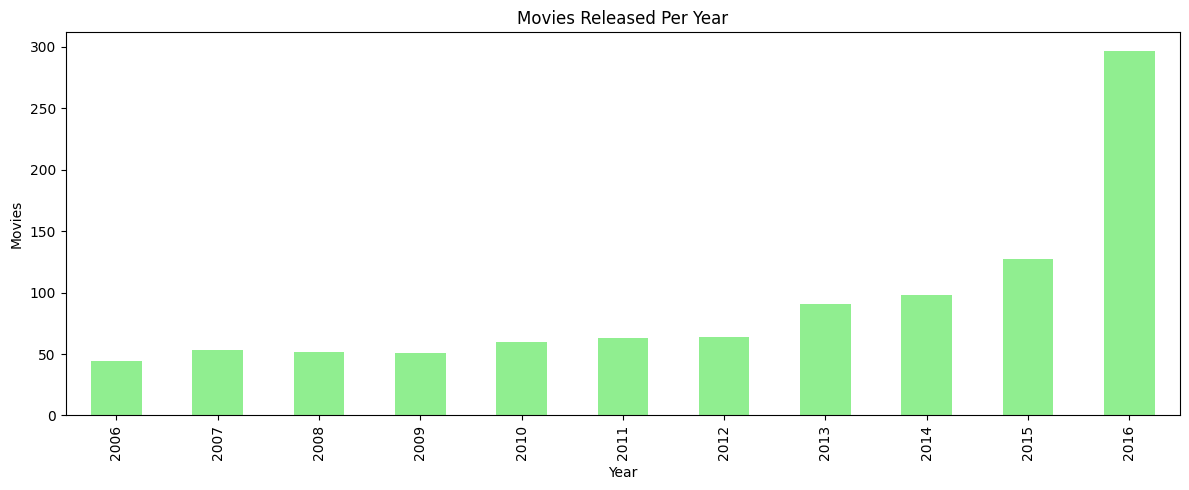


Graph 13: Average rating over years


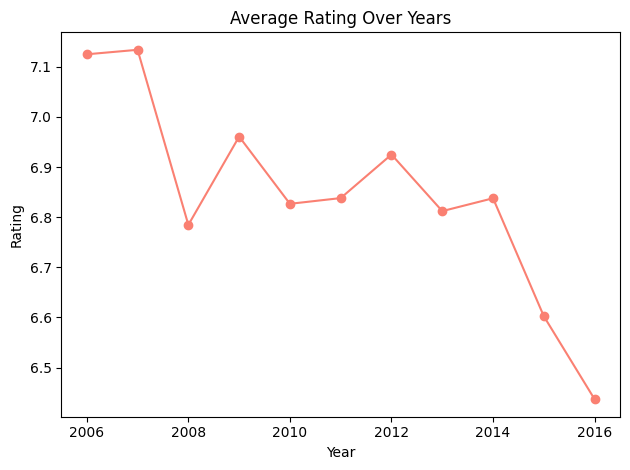


Objective 7: Finding Connections
Correlations:
                      Rating     Votes  Revenue (Millions)  Runtime (Minutes)  \
Rating              1.000000  0.511537            0.189527           0.392214   
Votes               0.511537  1.000000            0.607941           0.407062   
Revenue (Millions)  0.189527  0.607941            1.000000           0.247834   
Runtime (Minutes)   0.392214  0.407062            0.247834           1.000000   
Metascore           0.604522  0.317268            0.131868           0.202079   

                    Metascore  
Rating               0.604522  
Votes                0.317268  
Revenue (Millions)   0.131868  
Runtime (Minutes)    0.202079  
Metascore            1.000000  

Graph 14: Correlation heatmap


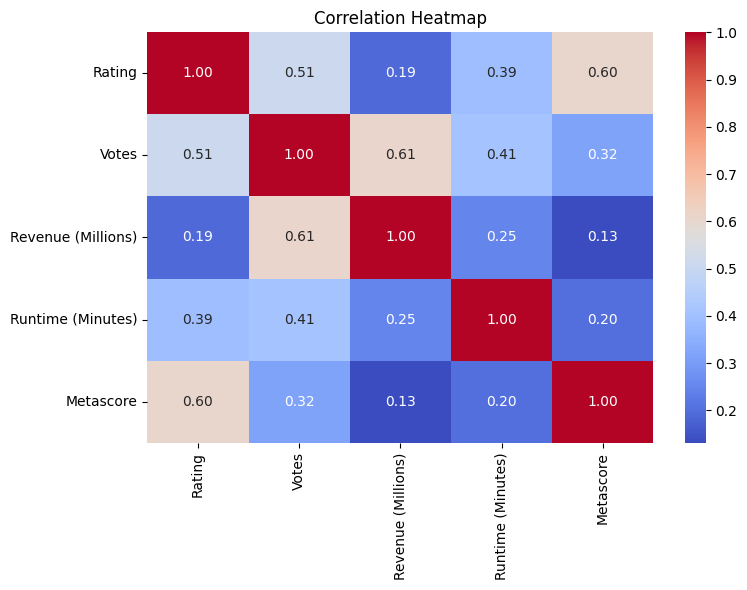


Graph 15: Rating and Votes vs. Revenue


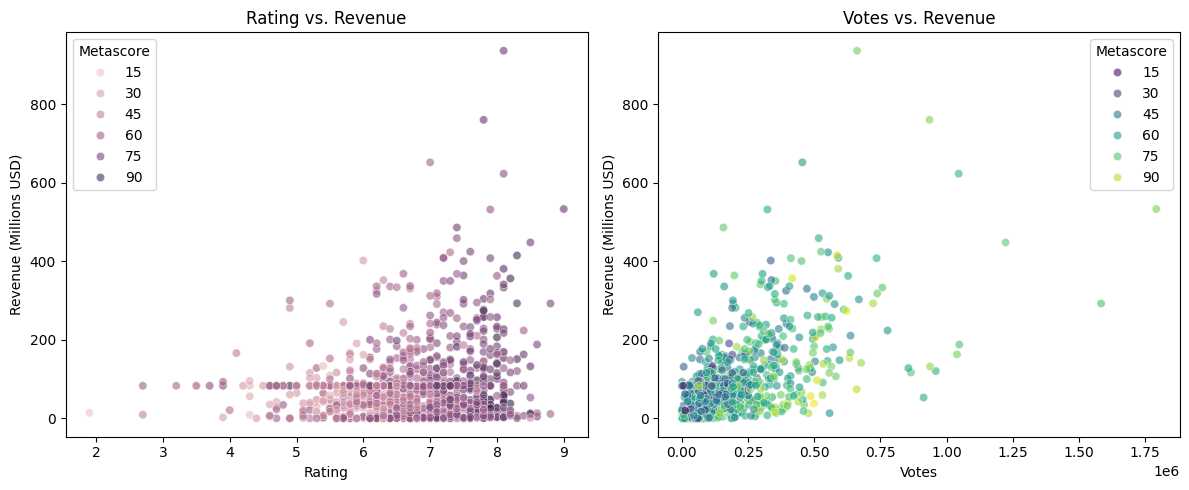


Graph 16: Revenue outliers


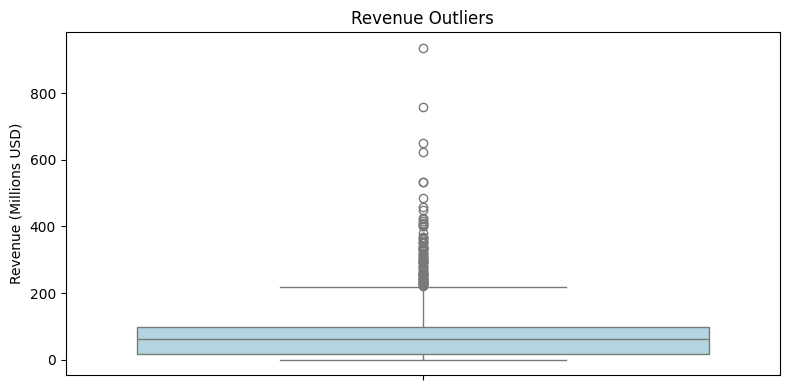


Objective 8: Easy Stats Intro

Mean and Median Rating:
Mean Rating: 6.7
Median Rating: 6.8

Graph 17: Rating histogram!


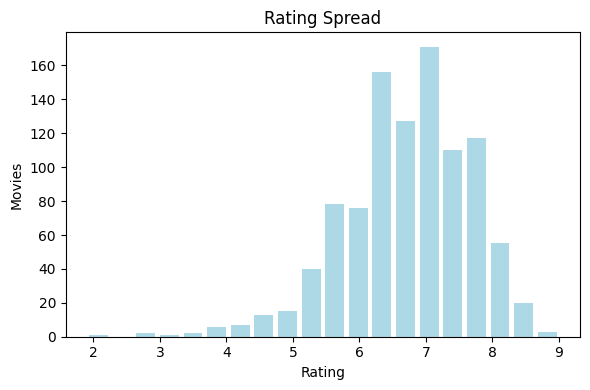


Shapiro-Wilk Test for Rating:
P-value: 0.0000
Not normal!

Graph 18: Rating distribution!


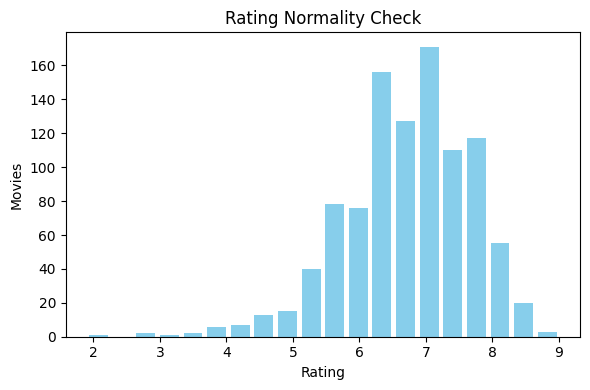


Normal Distribution:

Graph 19: Simulated normal rating!


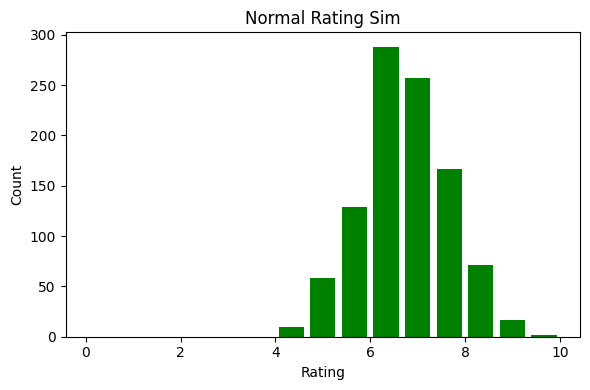


T-test: Drama vs. Action Revenue:
P-value: 0.0000
Different revenues!

Graph 20: Revenue for Drama and Action!


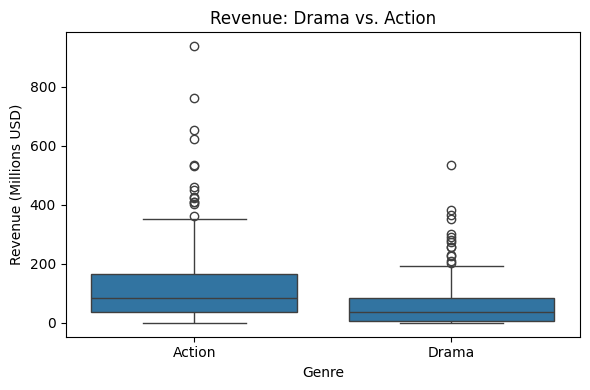


Done! Favorite movie stat?


In [4]:
print("Explanatory Data Analysis on IMDB Movie Dataset")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_ind



# Loading the movie dataset
print("Loading the data set")
df = pd.read_csv('IMDB-Movie-Data (1).csv')

# Objective 1: Getting to Know Our Movies
print("\nObjective 1: Getting to Know Our Movies")
print("First few movies:")
print(df.head())
print("\nLast couple:")
print(df.tail(2))
print("\nRandom pick:")
print(df.sample(2))

print(f"\nMovies: {df.shape[0]}, Columns: {df.shape[1]}")
print("Columns:", df.columns.tolist())
print("\nData info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Fill missing values
df = df.copy()  # Keeping the original safe
print("\nFilling missing revenue with mean, Metascore with median...")
df['Revenue (Millions)'] = df['Revenue (Millions)'].fillna(df['Revenue (Millions)'].mean())
df['Metascore'] = df['Metascore'].fillna(df['Metascore'].median())
print("Missing values now:")
print(df.isnull().sum())

print("\nBasic stats:")
print(df.describe())
print("\nDuplicates:", df.duplicated().sum())

print("\nTop 10 genres:")
print(df['Genre'].value_counts().head(10))

print("\nGraph 1: Rating distribution")
sns.histplot(df['Rating'], bins=20, color='skyblue')
plt.title("Movie Ratings")
plt.xlabel("Rating (out of 10)")
plt.ylabel("Movies")
plt.tight_layout()
plt.show()

# Objective 2: Does a High Rating Mean Big Bucks?
print("\nObjective 2: Do High Ratings Bring in the Cash?")
print("Correlations:")
print(df[['Rating', 'Metascore', 'Revenue (Millions)']].corr())

print("\nGraph 2: Rating and Metascore vs. Revenue")
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Rating', y='Revenue (Millions)', data=df, color='blue', alpha=0.5, label='Rating')
sns.scatterplot(x='Metascore', y='Revenue (Millions)', data=df, color='green', alpha=0.5, label='Metascore')
plt.title("Ratings and Metascore vs. Revenue")
plt.xlabel("Rating or Metascore")
plt.ylabel("Revenue (Millions USD)")
plt.legend()
plt.tight_layout()
plt.show()

print("\nAverage revenue by rating levels:")
rating_bins = pd.cut(df['Rating'], bins=[0, 5, 6.5, 8, 10], labels=['Low (0-5)', 'Okay (5-6.5)', 'Good (6.5-8)', 'Great (8-10)'])
print(df.groupby(rating_bins, observed=True)['Revenue (Millions)'].mean())

print("\nGraph 3: Revenue by rating groups")
plt.figure(figsize=(10, 6))
sns.boxplot(x=rating_bins, y='Revenue (Millions)', hue=rating_bins, data=df, palette='pastel', legend=False)
plt.title("Revenue by Rating Groups")
plt.xlabel("Rating Range")
plt.ylabel("Revenue (Millions USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Objective 3: How Many Movies Over the Years?
print("\nObjective 3: Movies Over the Years")
movies_per_year = df['Year'].value_counts().sort_index()
print("Movies per year:\n", movies_per_year)

print("\nGraph 4: Movies per year (line)")
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values, marker='o', color='purple')
plt.title("Movies Released Each Year")
plt.xlabel("Year")
plt.ylabel("Movies")
plt.tight_layout()
plt.show()

print("\nGraph 5: Movies per year (bar)")
sns.barplot(x=movies_per_year.index, y=movies_per_year.values)
plt.title("Movies Per Year")
plt.xlabel("Year")
plt.ylabel("Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nBusiest year:", movies_per_year.idxmax(), "with", movies_per_year.max(), "movies")
print("Quietest year:", movies_per_year.idxmin(), "with", movies_per_year.min(), "movies")

# Objective 4: What’s the Deal with Genres?
print("\nObjective 4: Exploring Genres")
df_genre = df.copy()
df_genre['Genre'] = df_genre['Genre'].str.split(',')
df_genre = df_genre.explode('Genre')
df_genre['Genre'] = df_genre['Genre'].str.strip()

print("\nMost common genres:")
genre_counts = df_genre['Genre'].value_counts()
print("\nGraph 6: Popular genres")
genre_counts.plot(kind='bar', figsize=(12, 6), color='teal')
plt.title("Most Popular Genres")
plt.xlabel("Genre")
plt.ylabel("Movies")
plt.tight_layout()
plt.show()

print("\nGraph 7: Average rating by genre")
avg_rating = df_genre.groupby('Genre')['Rating'].mean().sort_values(ascending=False)
avg_rating.plot(kind='barh', color='coral')
plt.title("Average Rating by Genre")
plt.xlabel("Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

print("\nGraph 8: Average revenue by genre")
avg_revenue = df_genre.groupby('Genre')['Revenue (Millions)'].mean().sort_values(ascending=False)
avg_revenue.plot(kind='barh', color='gold')
plt.title("Average Revenue by Genre")
plt.xlabel("Revenue (Millions USD)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

# Objective 5: Who’s the Director Star?
print("\nObjective 5: Spotlight on Directors")
print("Missing directors:", df['Director'].isnull().sum())

print("\nTop 10 directors by movie count:")
top_directors = df['Director'].value_counts().head(10)
print("\nGraph 9: Directors with most movies")
top_directors.plot(kind='barh', color='slateblue')
plt.title("Directors with Most Movies")
plt.xlabel("Movies")
plt.ylabel("Director")
plt.tight_layout()
plt.show()

print("\nGraph 10: Top directors by average rating")
avg_rating_director = df.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10)
avg_rating_director.plot(kind='barh', color='orchid')
plt.title("Top Directors by Average Rating")
plt.xlabel("Rating")
plt.ylabel("Director")
plt.tight_layout()
plt.show()

print("\nGraph 11: Directors with most high-rated movies (8+)")
high_rated = df[df['Rating'] >= 8.0]
top_high_rated_directors = high_rated['Director'].value_counts().head(10)
top_high_rated_directors.plot(kind='bar', color='darkcyan')
plt.title("Directors with Most High-Rated Movies (8+)")
plt.xlabel("Director")
plt.ylabel("High-Rated Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Objective 6: How Have Movies Changed Over Time?
print("\nObjective 6: Movie Trends Over Time")
print("\nGraph 12: Movies per year")
movies_per_year.plot(kind='bar', figsize=(12, 5), color='lightgreen')
plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Movies")
plt.tight_layout()
plt.show()

print("\nGraph 13: Average rating over years")
avg_rating_per_year = df.groupby('Year')['Rating'].mean()
avg_rating_per_year.plot(marker='o', linestyle='-', color='salmon')
plt.title("Average Rating Over Years")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

# Objective 7: What’s Connected in the Numbers?
print("\nObjective 7: Finding Connections")
numeric_cols = ['Rating', 'Votes', 'Revenue (Millions)', 'Runtime (Minutes)', 'Metascore']
print("Correlations:")
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

print("\nGraph 14: Correlation heatmap")
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("\nGraph 15: Rating and Votes vs. Revenue")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='Rating', y='Revenue (Millions)', hue='Metascore', data=df, alpha=0.6)
plt.title("Rating vs. Revenue")
plt.xlabel("Rating")
plt.ylabel("Revenue (Millions USD)")
plt.subplot(1, 2, 2)
sns.scatterplot(x='Votes', y='Revenue (Millions)', hue='Metascore', data=df, palette='viridis', alpha=0.6)
plt.title("Votes vs. Revenue")
plt.xlabel("Votes")
plt.ylabel("Revenue (Millions USD)")
plt.tight_layout()
plt.show()

print("\nGraph 16: Revenue outliers")
plt.figure(figsize=(8, 4))
sns.boxplot(y='Revenue (Millions)', data=df, color='lightblue')
plt.title("Revenue Outliers")
plt.ylabel("Revenue (Millions USD)")
plt.tight_layout()
plt.show()


# Objective 8: Easy Stats Intro
print("\nObjective 8: Easy Stats Intro")

# 1. Descriptive Stats
print("\nMean and Median Rating:")
print(f"Mean Rating: {df['Rating'].mean():.1f}")
print(f"Median Rating: {df['Rating'].median():.1f}")
plt.figure(figsize=(6, 4))
plt.hist(df['Rating'], bins=20, color='lightblue', rwidth=0.8)  # Added rwidth for gap
plt.title("Rating Spread")
plt.xlabel("Rating")
plt.ylabel("Movies")
print("\nGraph 17: Rating histogram!")
plt.tight_layout()
plt.show()

# 2. Shapiro-Wilk
print("\nShapiro-Wilk Test for Rating:")
stat, p = shapiro(df['Rating'])
print(f"P-value: {p:.4f}")
print("Normal curve?" if p > 0.05 else "Not normal!")
plt.figure(figsize=(6, 4))
plt.hist(df['Rating'], bins=20, color='skyblue', rwidth=0.8)  # Added rwidth for gap
plt.title("Rating Normality Check")
plt.xlabel("Rating")
plt.ylabel("Movies")
print("\nGraph 18: Rating distribution!")
plt.tight_layout()
plt.show()

# 3. Normal Distribution
print("\nNormal Distribution:")
m = df['Rating'].mean()
s = df['Rating'].std()
norm_data = np.random.normal(m, s, 1000)  # Increased to 1000
plt.figure(figsize=(6, 4))
plt.hist(norm_data, bins=15, color='green', rwidth=0.8, range=(0, 10))  # Added rwidth for gap
plt.title("Normal Rating Sim")
plt.xlabel("Rating")
plt.ylabel("Count")
print("\nGraph 19: Simulated normal rating!")
plt.tight_layout()
plt.show()

# 4. T-test
print("\nT-test: Drama vs. Action Revenue:")
drama = df_genre[df_genre['Genre'] == 'Drama']['Revenue (Millions)'].dropna()
action = df_genre[df_genre['Genre'] == 'Action']['Revenue (Millions)'].dropna()
t_stat, p = ttest_ind(drama, action, equal_var=False)  # Welch's t-test
print(f"P-value: {p:.4f}")
print("Different revenues!" if p < 0.05 else "Similar revenues!")
plt.figure(figsize=(6, 4))
sns.boxplot(x='Genre', y='Revenue (Millions)', data=df_genre[df_genre['Genre'].isin(['Drama', 'Action'])])
plt.title("Revenue: Drama vs. Action")
plt.xlabel("Genre")
plt.ylabel("Revenue (Millions USD)")
print("\nGraph 20: Revenue for Drama and Action!")
plt.tight_layout()
plt.show()

print("\nDone! Favorite movie stat?")